这是medmcqa数据集，训练和测试模型的时候用的是 '/home/qluai/zjs/MedMCQA数据处理/medmcqa/dev.json'，也就是验证集。 

注意是3.12.11这个不是3.10

In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

所以真正的测试集_最终测试集，需要从训练集取了。也可以重新跑实验，但是没必要。

整体思路：

1. 首先加载最佳模型

2. 在之前的测试集上选择最佳阈值 (这是最关键一步)

3. 在新的 “最终测试集”衡量 (这也是对第一步方法的一个衡量)

In [ ]:
#首先加载最佳模型

In [ ]:
# -*- coding: utf-8 -*-
"""
Multi-seed comparison of LR & MLP architectures + uncertainty baselines (PRR-focused)
====================================================================================
•  Runs each trainable model under several random seeds, aggregates PRR (mean ± std).
•  Identifies the **single best PRR run** (model, seed) and the **mean-best model**.
•  Plots PRR bar chart:   Best-Single  |  Best-Mean  |  External baselines.
•  Data paths & baseline numbers stay *exactly* as provided by the user.
"""

# ───────────────────────── Imports & Config ──────────────────────────────
import json, math
from typing import Dict, List, Sequence, Any
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# ----- user-provided file paths (DON'T TOUCH) -----
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"

# ----- model space & seeds -----
MLP_SPACE: Sequence[tuple] = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
RANDOM_SEEDS: Sequence[int] = [42, 7, 99, 123, 2025]
SPLIT_SEED: int = 42   # fixed split to keep test set constant
# ----- external baselines (unchanged) -----
BASELINES: Dict[str, Dict[str, float]] = {
    "Entropy": {"auroc": 0.6483933657229017, "prr": 0.3815520446222122},
    "SemanticEntropy": {"auroc": 0.6476796783380802, "prr": 0.3817748340535589},
    "MARS": {"auroc": 0.6403853241749036, "prr": 0.25004691695443415},
    "LARS": {"auroc": 0.5826101524543474, "prr": 0.11998820589573395},
    "SentSAR": {"auroc": 0.6407187133523202, "prr": 0.3189377757991942},
    "TokenSAR": {"auroc": 0.6365890433908528, "prr": 0.3661800406334507},
    "Confidence": {"auroc": 0.6349790584687552, "prr": 0.36465069833780245},
    "Inside": {"auroc": 0.5936890601440777, "prr": 0.15551997927986438},
    "AttentionScore": {"auroc": 0.4860914726084771, "prr": -0.035257024229759994},
    "EccentricityUncertainty": {"auroc": 0.5916066342770985, "prr": 0.1438465037441849},
    "EccentricityConfidence": {"auroc": 0.5925933992293517, "prr": 0.15049412105357587},
    "MatrixDegreeConfidence": {"auroc": 0.4933891774166527, "prr": -0.04051003303436451},
    "MatrixDegreeUncertainty": {"auroc": 0.5055855252136037, "prr": -0.015018937276435612},
    "SumEigenUncertainty": {"auroc": 0.5060579661584855, "prr": -0.014505404629913957},
    "PTrue": {"auroc": 0.6120706986094824, "prr": 0.218298100547547},
    "VerbalizedConfidence": {"auroc": 0.5624811526218797, "prr": 0.26941228944538265},
    "SelfDetection": {"auroc": 0.50031998659742, "prr": 0.0016730700215816334},
    "DirectionalEntailmentGraph": {"auroc": 0.5883581839504105, "prr": 0.06913171102167469},
}

# ───────────────────────── PRR utilities ────────────────────────────────

def _normalize(a: np.ndarray) -> np.ndarray:
    lo, hi = a.min(), a.max()
    return np.zeros_like(a) if math.isclose(lo, hi) else (a - lo) / (hi - lo)

def _prediction_rejection_curve(est, tgt):
    tgt = _normalize(tgt)
    order = np.argsort(est)[::-1]
    cum = np.cumsum(tgt[order])
    return (cum / np.arange(1, len(est) + 1)).mean()

def _random_prr(tgt, num_iter=1000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(tgt))
    vals = [_prediction_rejection_curve(rng.permutation(idx), tgt) for _ in range(num_iter)]
    return float(np.mean(vals))

def calc_prr(y_true: np.ndarray, y_score: np.ndarray, seed=0) -> float:
    ue = _prediction_rejection_curve(y_score, y_true)
    orc = _prediction_rejection_curve(y_true, y_true)
    rnd = _random_prr(y_true, seed=seed)
    denom = orc - rnd
    return 0.0 if math.isclose(denom, 0) else (ue - rnd) / denom

# ───────────────────────── Core training loop ───────────────────────────

def load_data(path: str):
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    X = np.array([it["normalized_truth_values"] for it in d])
    y = np.array([it["label"] for it in d])
    return X, y


def train_eval_multi_seed(X_tr, y_tr, X_te, y_te, seeds=RANDOM_SEEDS):
    """Return per-model list of PRR across seeds + best single record."""
    prr_records: Dict[str, List[float]] = {}
    best_single = {"model": None, "seed": None, "prr": -float("inf")}

    for seed in seeds:
        # ----- Logistic Regression -----
        lr = LogisticRegression(max_iter=1000, random_state=seed).fit(X_tr, y_tr)
        prr_lr = calc_prr(y_te, lr.predict_proba(X_te)[:, 1], seed)
        prr_records.setdefault("LR", []).append(prr_lr)
        if prr_lr > best_single["prr"]:
            best_single.update({"model": "LR", "seed": seed, "prr": prr_lr})

        # ----- MLPs -----
        for hid in MLP_SPACE:
            name = "MLP" + "x".join(map(str, hid))
            mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=seed).fit(X_tr, y_tr)
            prr_mlp = calc_prr(y_te, mlp.predict_proba(X_te)[:, 1], seed)
            prr_records.setdefault(name, []).append(prr_mlp)
            if prr_mlp > best_single["prr"]:
                best_single.update({"model": name, "seed": seed, "prr": prr_mlp})

    return prr_records, best_single

# ───────────────────────── Aggregation & Plot ───────────────────────────

def aggregate(prr_dict: Dict[str, List[float]]):
    return pd.DataFrame([
        {"model": m, "prr_mean": float(np.mean(vals)), "prr_std": float(np.std(vals, ddof=0))}
        for m, vals in prr_dict.items()
    ])


def plot_prr(best_single: Dict[str, Any], best_mean: Dict[str, Any]):
    labels = [
        f"Best-Single\n{best_single['model']}\nseed={best_single['seed']}",
        f"Best-Mean\n{best_mean['model']}",
    ] + list(BASELINES.keys())

    prr_vals = [best_single["prr"], best_mean["prr_mean"]] + [v["prr"] for v in BASELINES.values()]
    colors = ["crimson", "darkorange"] + ["steelblue"] * len(BASELINES)

    plt.figure(figsize=(13, 5))
    bars = plt.bar(labels, prr_vals, color=colors)
    plt.ylabel("PRR")
    plt.title("Best (Single & Mean) vs Uncertainty Baselines — PRR")
    plt.xticks(rotation=90, fontsize=8)
    for bar, val in zip(bars, prr_vals):
        plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# ───────────────────────── Main ─────────────────────────────────────────

def main():
    # 1) data split (fixed)
    X, y = load_data(TRAIN_TEST_FILE_PATH)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SPLIT_SEED, stratify=y)

    # 2) multi-seed training/eval
    prr_dict, best_single = train_eval_multi_seed(X_tr, y_tr, X_te, y_te)
    df = aggregate(prr_dict)

    # 3) mean-best model
    best_mean_row = df.loc[df["prr_mean"].idxmax()]
    best_mean = best_mean_row.to_dict()

    # 4) console summary
    pd.set_option("display.float_format", lambda x: f"{x:.4f}")
    print("\n========= PRR (mean ± std across seeds) =========")
    print(df.to_string(index=False))
    print(f"\n🌱 Best single PRR -> Model: {best_single['model']}, Seed: {best_single['seed']}, PRR={best_single['prr']:.4f}")
    print(f"📊 Best mean PRR   -> Model: {best_mean['model']}, PRR_mean={best_mean['prr_mean']:.4f} ± {best_mean['prr_std']:.4f}")

    # 5) visualization
    plot_prr(best_single, best_mean)


if __name__ == "__main__":
    main()


In [ ]:
#接下来是加载真正的“最终测试集”——从训练集取

# 应该还是要构造和之前一样的数据集

处理数据集以适应“calibrate_truth_method”函数，跑一遍即可

In [ ]:
import json
import random # 1. 【新增】导入 random 模块用于抽样

# --- 配置 ---
# 输入文件名：包含您原始数据的文件
INPUT_FILENAME = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/train.json'
# 输出文件名：我们为抽样后的输出文件起一个新的名字，以防覆盖
OUTPUT_FILENAME = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl'
# 【新增】定义需要抽取的样本数量
SAMPLE_SIZE = 5000

def process_and_sample_dataset(input_path, output_path, sample_size):
    """
    加载自定义多项选择题数据集，从中随机抽取指定数量的样本，
    然后将抽取的样本转换为 TruthTorchLM 的标准格式。

    Args:
        input_path (str): 原始数据文件路径 (.json 或 .jsonl 格式)。
        output_path (str): 处理后数据的保存路径 (.jsonl 格式)。
        sample_size (int): 需要随机抽取的样本数量。
    """
    print(f"开始加载原始数据: {input_path}")
    
    # 1. 加载原始数据
    try:
        questions_data = []
        with open(input_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    questions_data.append(json.loads(line))
    except FileNotFoundError:
        print(f"错误：输入文件未找到 -> {input_path}")
        return

    print(f"已加载 {len(questions_data)} 条数据。")

    # 2. 【新增】随机抽样
    #    为了保证实验的可复现性，可以设置一个随机种子
    random.seed(42) 
    
    # 检查总数据量是否足够抽样
    if len(questions_data) < sample_size:
        print(f"警告：数据总量 ({len(questions_data)}) 小于指定的抽样数量 ({sample_size})。将使用所有已加载的数据。")
        sampled_data = questions_data
    else:
        print(f"开始从 {len(questions_data)} 条数据中随机抽取 {sample_size} 条...")
        sampled_data = random.sample(questions_data, sample_size)

    print(f"已抽取 {len(sampled_data)} 条数据。开始进行格式化处理...")

    # 3. 定义选项的映射关系
    option_keys = ['opa', 'opb', 'opc', 'opd']
    option_labels = ['A)', 'B)', 'C)', 'D)']
    
    formatted_dataset = []

    # 4. 【修改】遍历并转换抽样后的每一条数据
    #    将循环对象从 'questions_data' 修改为 'sampled_data'
    for item in sampled_data:
        # 确保 'cop' 字段存在且为整数
        if 'cop' not in item or not isinstance(item['cop'], int):
            print(f"警告：跳过数据 (ID: {item.get('id')})，因为它缺少 'cop' 字段或格式不正确。")
            continue
        
        correct_option_index = item['cop']
        
        # 验证 'cop' 索引的有效性 (应为 1, 2, 3, 或 4)
        if not (1 <= correct_option_index <= len(option_keys)):
            print(f"警告：跳过数据 (ID: {item.get('id')})，因为 'cop' 值 ({correct_option_index}) 超出有效范围。")
            continue

        # 将 1-based 索引转换为 0-based 列表索引 (e.g., 1 -> 0)
        list_index = correct_option_index - 1
        
        correct_option_key = option_keys[list_index]
        correct_option_label = option_labels[list_index]
        
        # 提取答案的文本
        ground_truth_text = item.get(correct_option_key, "")

        # 将选项标签和答案文本拼接，形成最终的标准答案
        final_ground_truth = f"{correct_option_label} {ground_truth_text}"

        # 构建包含问题和所有选项的完整问题文本
        question_with_options = (
            f"{item.get('question', '')}\n"
            f"A) {item.get('opa', 'N/A')}\n"
            f"B) {item.get('opb', 'N/A')}\n"
            f"C) {item.get('opc', 'N/A')}\n"
            f"D) {item.get('opd', 'N/A')}"
        )

        # 按照最终确定的标准格式，组装字典
        formatted_item = {
            "context": "",
            "question": question_with_options,
            "ground_truths": [final_ground_truth]
        }
        formatted_dataset.append(formatted_item)

    # 5. 保存处理好的数据
    try:
        with open(output_path, 'w', encoding='utf-8') as f:
            for entry in formatted_dataset:
                f.write(json.dumps(entry, ensure_ascii=False) + '\n')
    except IOError as e:
        print(f"错误：无法写入输出文件 -> {output_path}。错误信息: {e}")
        return

    print(f"处理完成！已成功将 {len(formatted_dataset)} 条抽样数据保存到: {output_path}")


# --- 主程序入口 ---
if __name__ == '__main__':
    process_and_sample_dataset(INPUT_FILENAME, OUTPUT_FILENAME, SAMPLE_SIZE)

开始加载这5000条数据 /home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl

In [2]:
import json
processed_dataset_path = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl'
my_test_dataset = []
try:
    with open(processed_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                my_test_dataset.append(json.loads(line))
    print(f"成功加载处理好的数据集: {processed_dataset_path}")
except FileNotFoundError:
    print(f"错误：找不到处理好的数据集文件 -> {processed_dataset_path}")
    print("请先运行上一步 代码！")
    exit() # 如果文件不存在，则退出



成功加载处理好的数据集: /home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl


还需要加载之前的校准数据集


In [3]:
import json
processed_dataset_path = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/dev_formatted_dataset.jsonl'
my_custom_dataset = []
try:
    with open(processed_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                my_custom_dataset.append(json.loads(line))
    print(f"成功加载处理好的数据集: {processed_dataset_path}")
except FileNotFoundError:
    print(f"错误：找不到处理好的数据集文件 -> {processed_dataset_path}")
    print("请先运行 process_data.py 脚本！")
    exit() # 如果文件不存在，则退出



成功加载处理好的数据集: /home/qluai/zjs/MedMCQA数据处理/medmcqa/dev_formatted_dataset.jsonl


In [4]:
len(my_custom_dataset)

4183

In [4]:
dataset_for_calibrating = my_custom_dataset[:500]

In [5]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
import TruthTorchLM as ttlm
from transformers import AutoModelForCausalLM, AutoTokenizer
import os


os.environ["OPENAI_API_KEY"] = 'sk-kydgPim7qKMOHeX77f8fBd194c364a429106Ff96323b39E2'
os.environ["OPENAI_API_BASE"] = "https://api.xty.app/v1"
import torch

#define a huggingface model or api-based model
model = AutoModelForCausalLM.from_pretrained("/mnt/zhangjinshuo/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28", torch_dtype=torch.bfloat16,device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("/mnt/zhangjinshuo/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28", use_fast=False)

api_model = "gpt-4o-mini"

print(model.hf_device_map)



from sentence_transformers.cross_encoder import CrossEncoder
from transformers import (
    PreTrainedModel,
    PreTrainedTokenizer,
    PreTrainedTokenizerFast,
    DebertaForSequenceClassification,
    DebertaTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSequenceClassification,
)

Deberta_model_path = "/home/qluai/.cache/huggingface/hub/models--microsoft--deberta-large-mnli/snapshots/7296194b9009373def4f7c5dad292651e4b5cf4e/"
Deberta_model = DebertaForSequenceClassification.from_pretrained(Deberta_model_path).to("cuda:0")
Deberta_tokenizer = DebertaTokenizer.from_pretrained(Deberta_model_path)
Entropy = ttlm.truth_methods.Entropy()#不用加载模型

Semantic_entropy = ttlm.truth_methods.SemanticEntropy(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)#需要加载模型 microsoft/deberta-large-mnli

Mars = ttlm.truth_methods.MARS()#需要加载模型 duygunuryldz/MARS

Lars = ttlm.truth_methods.LARS(device='cuda:1')#需要加载模型 duygunuryldz/LARS，应该在.cache

SentSAR = ttlm.truth_methods.SentSAR()#需要加载模型 cross-encoder/stsb-roberta-large

TokenSAR = ttlm.truth_methods.TokenSAR()#需要加载模型 cross-encoder/stsb-roberta-large

Confidence = ttlm.truth_methods.Confidence()#不用加载模型 average log probality of the generated message

Inside = ttlm.truth_methods.Inside()#不用加载模型

AttentionScore = ttlm.truth_methods.AttentionScore()#不用加载模型

EccentricityUncertainty = ttlm.truth_methods.EccentricityUncertainty(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)#需要加载模型 microsoft/deberta-large-mnli

EccentricityConfidence = ttlm.truth_methods.EccentricityConfidence(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)# 需要加载模型 microsoft/deberta-large-mnli

MatrixDegreeConfidence = ttlm.truth_methods.MatrixDegreeConfidence(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)# 需要加载模型 microsoft/deberta-large-mnli

MatrixDegreeUncertainty = ttlm.truth_methods.MatrixDegreeUncertainty(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer) #需要加载模型 microsoft/deberta-large-mnli

SumEigenUncertainty = ttlm.truth_methods.SumEigenUncertainty(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)# 需要加载模型 microsoft/deberta-large-mnli

PTrue = ttlm.truth_methods.PTrue()# 不需要加载模型

VerbalizedConfidence = ttlm.truth_methods.VerbalizedConfidence()# 不需要加载模型

SelfDetection = ttlm.truth_methods.SelfDetection(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)# 需要加载模型 microsoft/deberta-large-mnli

DirectionalEntailmentGraph = ttlm.truth_methods.DirectionalEntailmentGraph(model_for_entailment=Deberta_model,tokenizer_for_entailment=Deberta_tokenizer)# 需要加载模型 microsoft/deberta-large-mnli

truth_methods = [Entropy, Semantic_entropy, Mars, Lars, SentSAR, TokenSAR, Confidence, Inside, AttentionScore, EccentricityUncertainty,  EccentricityConfidence,  MatrixDegreeConfidence,  MatrixDegreeUncertainty,   SumEigenUncertainty,  PTrue, VerbalizedConfidence, SelfDetection, DirectionalEntailmentGraph]#列表里可以填多个方法


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 0, 'model.layers.5': 0, 'model.layers.6': 0, 'model.layers.7': 0, 'model.layers.8': 0, 'model.layers.9': 0, 'model.layers.10': 0, 'model.layers.11': 0, 'model.layers.12': 1, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.norm': 1, 'model.rotary_emb': 1, 'lm_head': 1}


Some weights of the model checkpoint at /home/qluai/.cache/huggingface/hub/models--microsoft--deberta-large-mnli/snapshots/7296194b9009373def4f7c5dad292651e4b5cf4e/ were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


There are 2 methods for similarity: semantic similarity and jaccard score. The default method is semantic similarity. If you want to use jaccard score, please set method_for_similarity="jaccard". Please refer to https://arxiv.org/pdf/2305.19187 for more information.
There are 2 methods for similarity: semantic similarity and jaccard score. The default method is semantic similarity. If you want to use jaccard score, please set method_for_similarity="jaccard". Please refer to https://arxiv.org/pdf/2305.19187 for more information.
There are 2 methods for similarity: semantic similarity and jaccard score. The default method is semantic similarity. If you want to use jaccard score, please set method_for_similarity="jaccard". Please refer to https://arxiv.org/pdf/2305.19187 for more information.
There are 2 methods for similarity: semantic similarity and jaccard score. The default method is semantic similarity. If you want to use jaccard score, please set method_for_similarity="jaccard". Ple

In [6]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def send_email(subject, body, to_email="2643791302@qq.com"):
    from_email = "2643791302@qq.com"
    from_password = "grlmsluhgjsdecee"  # 注意是 QQ 授权码，不是密码！

    msg = MIMEMultipart()
    msg["From"] = from_email
    msg["To"] = to_email
    msg["Subject"] = subject
    msg.attach(MIMEText(body, "plain", "utf-8"))

    try:
        server = smtplib.SMTP_SSL("smtp.qq.com", 465)
        server.login(from_email, from_password)
        server.sendmail(from_email, to_email, msg.as_string())
        server.quit()
        print("✅ 邮件已发送")
    except Exception as e:
        print("❌ 邮件发送失败:", str(e))


进行校准

In [ ]:
import traceback
import logging
import time

# --- 日志记录设置 (推荐放在脚本开头) ---
# 为了避免覆盖，我们创建一个带时间戳的日志文件名
log_filename = f"calibration_task_{time.strftime('%Y%m%d_%H%M%S')}.log"

# 1. 获取一个 logger 对象
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO) # 设置该 logger 的最低响应级别为 INFO

# 2. 创建 handler，用于将日志写入文件和控制台
# 写入文件的 handler
file_handler = logging.FileHandler(log_filename, encoding='utf-8')
file_handler.setLevel(logging.INFO) # 文件记录所有 INFO 及以上级别的日志

# 输出到控制台的 handler
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO) # 控制台也显示 INFO 及以上级别的日志

# 3. 定义日志的输出格式
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

# 4. 将 handler 添加到 logger
# 避免重复添加，每次运行前先清空
if not logger.handlers:
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

# --- 任务执行代码 ---
task_success = False
error_trace = ""

try:
    logger.info("==================== 新的校准任务开始 ====================")
    logger.info(f"日志文件位于: {log_filename}")
    logger.info(f"使用模型: {getattr(model, 'name_or_path', str(model))}")
    logger.info(f"使用评估器 (Correctness Evaluator): '{api_model}'")
    logger.info(f"待校准的方法数量: {len(truth_methods)}")
    logger.info(f"用于校准的数据集样本数 (size_of_data): 10")

    model_judge = ttlm.evaluators.ModelJudge(api_model)

    logger.info("正在为每个 truth_method 设置 IsotonicRegression normalizer...")
    for truth_method in truth_methods:
        truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())
    logger.info("Normalizer 设置完成。")

    logger.info(">>> 开始执行核心函数: ttlm.calibrate_truth_method()...")
    calibration_results = ttlm.calibrate_truth_method(
        dataset=dataset_for_calibrating,
        model=model,
        truth_methods=truth_methods,
        tokenizer=tokenizer,
        correctness_evaluator=model_judge,
        size_of_data=10,
        return_method_details=True,
        seed=0,
        max_new_tokens=300,
        wandb_push_method_details=False,
        pad_token_id=tokenizer.eos_token_id
    )
    logger.info("<<< `calibrate_truth_method` 成功执行完毕。")

    task_success = True  # 任务成功

except Exception as e:
    # 使用 logger.error 并设置 exc_info=True 可以自动记录完整的异常堆栈信息
    logger.error("任务执行过程中发生严重错误！", exc_info=True)
    error_trace = traceback.format_exc() # 同时为邮件内容保留 traceback 字符串
    task_success = False

finally:
    logger.info("任务执行流程结束，进入 finally 块发送通知邮件。")
    if task_success:
        subject = "[TTLM] ✅ Truth method 校准成功"
        body = (
            f"calibrate_truth_method 成功完成。\n\n"
            f"方法数量：{len(truth_methods)}\n"
            f"模型：{getattr(model, 'name_or_path', str(model))}\n\n"
            f"详细运行过程请查看日志文件: {log_filename}"
        )
        logger.info("任务成功，准备发送成功邮件。")
        send_email(subject=subject, body=body)
    else:
        subject = "[TTLM] ❌ Truth method 校准失败"
        body = (
            f"校准过程中发生异常，错误信息摘要如下：\n\n{error_trace}\n"
            f"完整的错误堆栈信息请查看日志文件: {log_filename}"
        )
        logger.warning("任务失败，准备发送失败邮件。")
        send_email(subject=subject, body=body)

    logger.info("==================== 本次校准任务结束 ====================\n")

In [ ]:
# import traceback

# # 标记变量
# task_success = False
# error_trace = ""

# try:
#     model_judge = ttlm.evaluators.ModelJudge('gpt-4o-mini')
#     for truth_method in truth_methods:
#         truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())

#     calibration_results = ttlm.calibrate_truth_method(
#         dataset=dataset_for_calibrating, #注意此处的数据
#         model=model,
#         truth_methods=truth_methods,
#         tokenizer=tokenizer,
#         correctness_evaluator=model_judge,
#         size_of_data=10,
#         return_method_details=True,
#         seed=0,
#         max_new_tokens=300,
#         wandb_push_method_details=False,
#         pad_token_id=tokenizer.eos_token_id
#     )

#     task_success = True  # 成功标记

# except Exception as e:
#     error_trace = traceback.format_exc()
#     task_success = False
#     print("❌ 任务执行失败，将发送错误邮件...")

# finally:
#     # ✅ 无论成功与否都发邮件
#     if task_success:
#         send_email(
#             subject="[TTLM] ✅ Truth method 校准成功",
#             body="calibrate_truth_method 成功完成。\n"
#                  f"方法数量：{len(truth_methods)}\n"
#                  f"模型：{getattr(model, 'name_or_path', str(model))}"
#         )
#     else:
#         send_email(
#             subject="[TTLM] ❌ Truth method 校准失败",
#             body=f"校准过程中发生异常，错误信息如下：\n\n{error_trace}"
#         )


In [ ]:
# #we need a supervised dataset to calibrate the truth methods. We use trivia_qa dataset for this example.
# #we need a correctness evaluator to evaluate the truth methods. We use model_judge for this example. model_judge looks at the model's output and the ground truth and returns a correctness score.
# model_judge = ttlm.evaluators.ModelJudge('gpt-4o-mini')
# for truth_method in truth_methods:
#     truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())
# calibration_results = ttlm.calibrate_truth_method(dataset = dataset_for_calibrating, model = model, truth_methods = truth_methods, tokenizer = tokenizer, correctness_evaluator = model_judge, 
#     size_of_data = 10,  return_method_details = True, seed = 0, max_new_tokens = 300, wandb_push_method_details = False, pad_token_id=tokenizer.eos_token_id)

这一步比较关键，注意数据集选择，应该选用：my_test_dataset 

In [ ]:
from tqdm import tqdm
import math

results = []

total = len(my_test_dataset )# 第二个单元格已定义
percent_step = 10
step = max(1, total * percent_step // 100)  # 每处理 step 条数据发一次邮件

for idx, sample in enumerate(tqdm(my_test_dataset , desc="Processing samples")):
    try:
        chat = [
            {"role": "system", "content": "You are an expert at multiple-choice questions. According to the following question and options, respond with only the single, correct option, including its letter and full text."},
            {"role": "user", "content": sample['question']}
        ]



        #关键是调用generate_with_truth_value函数
        output = ttlm.generate_with_truth_value(
            model=model,
            tokenizer=tokenizer,
            messages=chat,
            truth_methods=truth_methods,
            max_new_tokens=300,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

        results.append({
            "question": sample['question'],
            "ground_truth": sample['ground_truths'][0],
            "output": output
        })

        # 每处理 10% 发一次邮件
        if (idx + 1) % step == 0 or (idx + 1) == total:
            percent_complete = ((idx + 1) / total) * 100
            send_email(
                subject=f"✅ 进度通知：已完成 {percent_complete:.0f}%",
                body=f"你提交的模型测试已完成约 {percent_complete:.0f}%。\n当前样本索引：{idx + 1} / {total}。"
            )

    except Exception as e:
        error_msg = f"❌ 运行中断：第 {idx + 1} 条样本出错\n错误信息：{str(e)}"
        print(error_msg)
        send_email(subject="❌ 运行出错通知", body=error_msg)
        break  # 你也可以选择 continue 而不是 break



In [9]:
import openai
import json
from tqdm.notebook import tqdm # 在Jupyter中，使用tqdm.notebook获得更好的进度条样式
import os
import httpx # 新增 httpx 库用于更稳定的网络请求

from openai import OpenAI


API_KEY = 'sk-kydgPim7qKMOHeX77f8fBd194c364a429106Ff96323b39E2'
BASE_URL = "https://api.xty.app/v1"

try:
    # 使用您提供的方式初始化客户端，以支持重定向
    client = OpenAI(
        base_url=BASE_URL,
        api_key=API_KEY,
        http_client=httpx.Client(
            # 注意：在 httpx.Client 中也指定 base_url 是一个好习惯
            base_url=BASE_URL, 
            # 允许客户端跟随HTTP重定向
            follow_redirects=True,
        ),
    )
    
    # 我们可以简单地尝试一个小请求来验证配置是否有效
    client.models.list() 
    print("✅ OpenAI 客户端初始化成功，配置有效！")
    
except Exception as e:
    print(f"❌ 初始化OpenAI客户端或验证配置时出错: {e}")
    print("   请检查您的API密钥和基础URL是否正确，以及网络连接是否正常。")



def get_label_from_gpt(ground_truth, generated_answer):
    """
    使用 gpt-4o-mini 判断两个答案是否语义一致。
    
    Args:
        ground_truth (str): 标准答案
        generated_answer (str): 模型生成的答案
    
    Returns:
        int: 如果一致返回 1，不一致返回 0，如果API调用出错返回 -1。
    """
    # System Prompt 指导模型如何行动，并严格规定了输出格式，这对于获取稳定结果至关重要
    system_prompt = (
        "You are a precise evaluator. Your task is to determine if a 'Generated Answer' is "
        "semantically identical to the 'Ground Truth' answer for a multiple-choice question. "
        "They are identical if they refer to the same option, even with minor formatting differences "
        "(e.g., 'A)' vs 'A.' or containing extra text like 'The answer is...'). "
        "Respond with only the single word 'yes' or 'no', and nothing else."
    )
    
    # User Prompt 提供了需要比对的具体内容
    user_prompt = f"Ground Truth: {ground_truth}\nGenerated Answer: {generated_answer}"

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",  # 使用您指定的 gpt-4o-mini 模型
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0,  # 使用 0 温度以获得更稳定、确定性的输出
            max_tokens=5    # 只需要返回 'yes' 或 'no'，5个token足够了
        )
        
        gpt_response = response.choices[0].message.content.strip().lower()
        
        if gpt_response == "yes":
            return 1
        else:
            return 0
            
    except Exception as e:
        print(f"调用 GPT API 时出错: {e}")
        print(f"出错的样本 -> Ground Truth: {ground_truth}, Generated Answer: {generated_answer}")
        return -1 # 使用 -1 来标记评估过程中出现的错误

print("✅ 评估函数 'get_label_from_gpt' 定义完成！")

# 我们将创建一个新的列表来存储带标签的结果
labeled_results = []

# 使用 tqdm 显示进度条
for item in tqdm(results, desc="正在使用 GPT-4o-mini 添加标签"):
    ground_truth = item['ground_truth']
    generated_text = item['output']['generated_text']
    
    # 调用函数获取标签
    label = get_label_from_gpt(ground_truth, generated_text)
    
    # 将新的 label 字段添加到项目中
    # 注意：这里我们是直接在原始 item 上修改，然后添加到新列表
    item['label'] = label
    labeled_results.append(item)

# 现在 labeled_results 包含了您需要的所有信息
# 您可以覆盖原来的 results 变量
results = labeled_results   #这里的results是上面调用得到的 generate_with_truth_value，这里相当于在之前的基础上又加了一个字段“label”
print(f"\n✅ 标签添加完成！共处理了 {len(results)} 条数据。")

✅ OpenAI 客户端初始化成功，配置有效！
✅ 评估函数 'get_label_from_gpt' 定义完成！


正在使用 GPT-4o-mini 添加标签:   0%|          | 0/5000 [00:00<?, ?it/s]


✅ 标签添加完成！共处理了 5000 条数据。


保存labeled文件，文件名需要改动

In [ ]:
# 为了解决 'ndarray is not JSON serializable' 的错误，
# 我们需要定义一个自定义的转换函数，告诉json库如何处理这些特殊类型。

import json
import os
import numpy as np

# 尝试              导入torch，因为数据中也可能包含PyTorch张量，但如果未安装也不报错
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False                   

def custom_serializer(obj):
    """
    自定义JSON序列化函数，用于处理默认库无法处理的对象。
    此函数将NumPy数值类型、数组和PyTorch张量转换为Python原生类型。
    """
    # 检查是否为NumPy的数值类型 (e.g., np.float32, np.int64)
    # 并将其转换为对应的Python原生类型 (e.g., float, int)
    if isinstance(obj, np.number):
        return obj.item()
    
    # 如果对象是NumPy数组，则调用 .tolist() 方法转换
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    
    # 如果torch已导入且对象是PyTorch张量，也调用 .tolist()
    if HAS_TORCH and isinstance(obj, torch.Tensor):
        return obj.tolist()
    
    # 对于其他任何json无法处理的类型，抛出原始的TypeError
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")


# 定义输出文件的名称
output_filename = 'step2_labeled_results.json'

try:
    with open(output_filename, 'w', encoding='utf-8') as f:
        # 使用 json.dump 保存，并通过 'default' 参数传入我们的自定义函数
        # indent=4 让JSON文件格式化，更易于阅读
        # ensure_ascii=False 确保中文等非ASCII字符能正确显示
        json.dump(results, f, ensure_ascii=False, indent=4, default=custom_serializer)
        
    print(f"✅ 成功！已将带标签的结果保存到文件: {os.path.abspath(output_filename)}")

except Exception as e:
    print(f"❌ 保存文件时出错: {e}")

# 打印第一条结果，检查 'label' 是否已成功添加
if results:
    print("\n第一条结果预览:")
    # 在打印预览时，同样需要使用我们的自定义序列化函数
    print(json.dumps(results[0], indent=4, ensure_ascii=False, default=custom_serializer))


✅ 成功！已将带标签的结果保存到文件: /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_labeled_results.json

第一条结果预览:
{
    "question": "Which of the following is true regarding major basic protein?\nA) Formed by Eosinophils\nB) Cytotoxic to parasites\nC) Not very effective against bacteria\nD) All the above",
    "ground_truth": "D) All the above",
    "output": {
        "generated_text": "D) All the above",
        "normalized_truth_values": [
            0.9122807017543859,
            0.9122807017543859,
            0.7241379310344828,
            0.68,
            0.6453009775338707,
            0.8,
            0.9090909090909091,
            0.532258064516129,
            0.542016806722689,
            0.580110497237569,
            0.580110497237569,
            0.5764705882352941,
            0.58125,
            0.58125,
            0.594059405940594,
            0.7941176470588235,
            0.5436105476673428,
            0.5953177257525084
        ],
        "unnormalized_t

保存简化后的数据，同样需要修改数据,到这一步，测试集数据已经准备完毕了

In [11]:
simplified_results = []

print(f"正在从 {len(results)} 条结果中提取关键字段...")
for item in results:
    try:
        # 3. 为每个条目创建一个新的字典，并提取所需字段
        new_entry = {
            'label': item['label'],
            'normalized_truth_values': item['output']['normalized_truth_values']
        }
        simplified_results.append(new_entry)
    except KeyError as e:
        print(f"处理其中一个条目时出错：缺少键 {e}。已跳过该条目。")

output_filename = 'step2_final_simplified_results.json'
try:
    with open(output_filename, 'w', encoding='utf-8') as f:
        # indent=4 让JSON文件格式化，更易于阅读
        json.dump(simplified_results, f, indent=4)
        
    print(f"\n✅ 成功！已将简化后的结果保存到文件: {os.path.abspath(output_filename)}")

except Exception as e:
    print(f"\n❌ 保存文件时出错: {e}")


if simplified_results:
    print("\n第一条简化结果预览:")
    print(json.dumps(simplified_results[0], indent=4))

正在从 5000 条结果中提取关键字段...

✅ 成功！已将简化后的结果保存到文件: /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json

第一条简化结果预览:
{
    "label": 1,
    "normalized_truth_values": [
        0.9122807017543859,
        0.9122807017543859,
        0.7241379310344828,
        0.68,
        0.6453009775338707,
        0.8,
        0.9090909090909091,
        0.532258064516129,
        0.542016806722689,
        0.580110497237569,
        0.580110497237569,
        0.5764705882352941,
        0.58125,
        0.58125,
        0.594059405940594,
        0.7941176470588235,
        0.5436105476673428,
        0.5953177257525084
    ]
}


（测试集）目前已经找到最终测试集：/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json

（训练+验证集）模型训练加测试数据集： /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json

（验证集）从第二个分离出的测试集：/home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/medmcqa_test_dataset.json   这个数据要去对应medqa文件夹中找

我要在验证集上找到最佳阈值，然后在测试集上进行测试

加载模型


========= PRR (mean ± std across seeds) =========
       model  prr_mean  prr_std
          LR    0.4784   0.0010
       MLP32    0.4715   0.0033
       MLP64    0.4703   0.0026
    MLP32x32    0.4646   0.0157
    MLP64x32    0.4632   0.0024
MLP128x64x32    0.4158   0.0380

🌱 Best single PRR -> Model: MLP32x32, Seed: 123, PRR=0.4820
📊 Best mean PRR   -> Model: LR, PRR_mean=0.4784 ± 0.0010


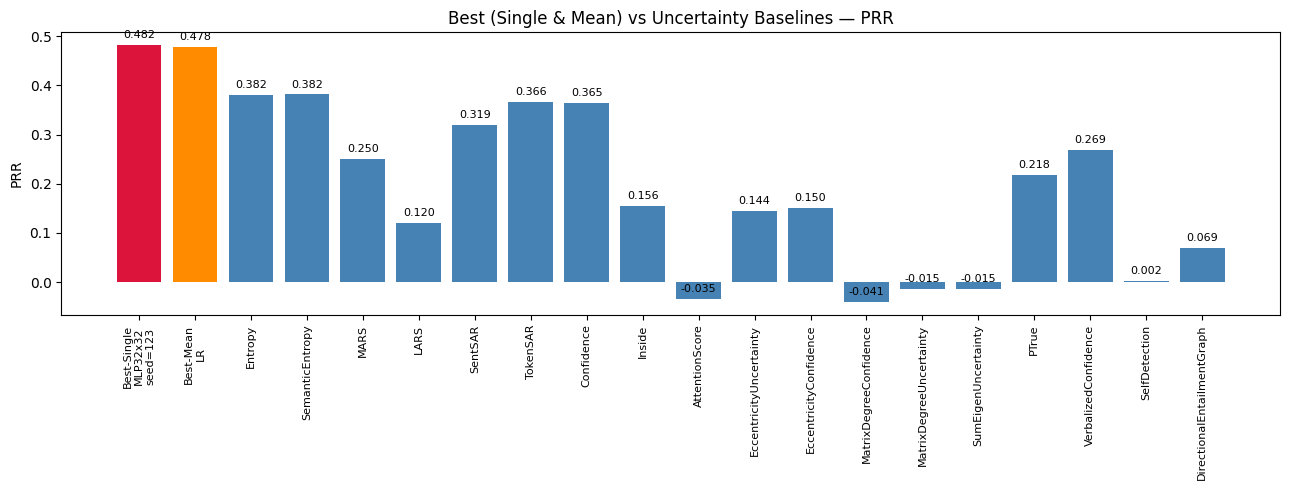


========= Retraining and Saving the Best Model =========
📈 The best overall model architecture is: LR
💪 Retraining the model on the full training set (X_tr, y_tr)...
✅ Model successfully saved to: '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/lr_qwen_best_model.joblib'


In [1]:
# -*- coding: utf-8 -*-
"""
Multi-seed comparison of LR & MLP architectures + uncertainty baselines (PRR-focused)
====================================================================================
•  Runs each trainable model under several random seeds, aggregates PRR (mean ± std).
•  Identifies the **single best PRR run** (model, seed) and the **mean-best model**.
•  Plots PRR bar chart:   Best-Single  |  Best-Mean  |  External baselines.
•  MODIFIED: Automatically retrains and saves the best-performing model architecture.
"""

# ───────────────────────── Imports & Config ──────────────────────────────
import json, math
import os
import joblib
from typing import Dict, List, Sequence, Any
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# ----- user-provided file paths (DON'T TOUCH) -----
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"

# ----- model space & seeds -----
MLP_SPACE: Sequence[tuple] = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
RANDOM_SEEDS: Sequence[int] = [42, 7, 99, 123, 2025]
SPLIT_SEED: int = 42   # fixed split to keep test set constant

# ----- external baselines (unchanged) -----
BASELINES: Dict[str, Dict[str, float]] = {
    "Entropy": {"auroc": 0.6483933657229017, "prr": 0.3815520446222122},
    "SemanticEntropy": {"auroc": 0.6476796783380802, "prr": 0.3817748340535589},
    "MARS": {"auroc": 0.6403853241749036, "prr": 0.25004691695443415},
    "LARS": {"auroc": 0.5826101524543474, "prr": 0.11998820589573395},
    "SentSAR": {"auroc": 0.6407187133523202, "prr": 0.3189377757991942},
    "TokenSAR": {"auroc": 0.6365890433908528, "prr": 0.3661800406334507},
    "Confidence": {"auroc": 0.6349790584687552, "prr": 0.36465069833780245},
    "Inside": {"auroc": 0.5936890601440777, "prr": 0.15551997927986438},
    "AttentionScore": {"auroc": 0.4860914726084771, "prr": -0.035257024229759994},
    "EccentricityUncertainty": {"auroc": 0.5916066342770985, "prr": 0.1438465037441849},
    "EccentricityConfidence": {"auroc": 0.5925933992293517, "prr": 0.15049412105357587},
    "MatrixDegreeConfidence": {"auroc": 0.4933891774166527, "prr": -0.04051003303436451},
    "MatrixDegreeUncertainty": {"auroc": 0.5055855252136037, "prr": -0.015018937276435612},
    "SumEigenUncertainty": {"auroc": 0.5060579661584855, "prr": -0.014505404629913957},
    "PTrue": {"auroc": 0.6120706986094824, "prr": 0.218298100547547},
    "VerbalizedConfidence": {"auroc": 0.5624811526218797, "prr": 0.26941228944538265},
    "SelfDetection": {"auroc": 0.50031998659742, "prr": 0.0016730700215816334},
    "DirectionalEntailmentGraph": {"auroc": 0.5883581839504105, "prr": 0.06913171102167469},
}

# ───────────────────────── PRR utilities (unchanged) ────────────────────

def _normalize(a: np.ndarray) -> np.ndarray:
    lo, hi = a.min(), a.max()
    return np.zeros_like(a) if math.isclose(lo, hi) else (a - lo) / (hi - lo)

def _prediction_rejection_curve(est, tgt):
    tgt = _normalize(tgt)
    order = np.argsort(est)[::-1]
    cum = np.cumsum(tgt[order])
    return (cum / np.arange(1, len(est) + 1)).mean()

def _random_prr(tgt, num_iter=1000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(tgt))
    vals = [_prediction_rejection_curve(rng.permutation(idx), tgt) for _ in range(num_iter)]
    return float(np.mean(vals))

def calc_prr(y_true: np.ndarray, y_score: np.ndarray, seed=0) -> float:
    ue = _prediction_rejection_curve(y_score, y_true)
    orc = _prediction_rejection_curve(y_true, y_true)
    rnd = _random_prr(y_true, seed=seed)
    denom = orc - rnd
    return 0.0 if math.isclose(denom, 0) else (ue - rnd) / denom

# ───────────────── Core training & plotting (unchanged) ─────────────────

def load_data(path: str):
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    X = np.array([it["normalized_truth_values"] for it in d])
    y = np.array([it["label"] for it in d])
    return X, y

def train_eval_multi_seed(X_tr, y_tr, X_te, y_te, seeds=RANDOM_SEEDS):
    prr_records: Dict[str, List[float]] = {}
    best_single = {"model": None, "seed": None, "prr": -float("inf")}
    for seed in seeds:
        lr = LogisticRegression(max_iter=1000, random_state=seed).fit(X_tr, y_tr)
        prr_lr = calc_prr(y_te, lr.predict_proba(X_te)[:, 1], seed)
        prr_records.setdefault("LR", []).append(prr_lr)
        if prr_lr > best_single["prr"]:
            best_single.update({"model": "LR", "seed": seed, "prr": prr_lr})
        for hid in MLP_SPACE:
            name = "MLP" + "x".join(map(str, hid))
            mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=seed).fit(X_tr, y_tr)
            prr_mlp = calc_prr(y_te, mlp.predict_proba(X_te)[:, 1], seed)
            prr_records.setdefault(name, []).append(prr_mlp)
            if prr_mlp > best_single["prr"]:
                best_single.update({"model": name, "seed": seed, "prr": prr_mlp})
    return prr_records, best_single

def aggregate(prr_dict: Dict[str, List[float]]):
    return pd.DataFrame([
        {"model": m, "prr_mean": float(np.mean(vals)), "prr_std": float(np.std(vals, ddof=0))}
        for m, vals in prr_dict.items()
    ])

def plot_prr(best_single: Dict[str, Any], best_mean: Dict[str, Any]):
    labels = [
        f"Best-Single\n{best_single['model']}\nseed={best_single['seed']}",
        f"Best-Mean\n{best_mean['model']}",
    ] + list(BASELINES.keys())
    prr_vals = [best_single["prr"], best_mean["prr_mean"]] + [v["prr"] for v in BASELINES.values()]
    colors = ["crimson", "darkorange"] + ["steelblue"] * len(BASELINES)
    plt.figure(figsize=(13, 5))
    bars = plt.bar(labels, prr_vals, color=colors)
    plt.ylabel("PRR")
    plt.title("Best (Single & Mean) vs Uncertainty Baselines — PRR")
    plt.xticks(rotation=90, fontsize=8)
    for bar, val in zip(bars, prr_vals):
        plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# ───────────────────────── Main ─────────────────────────────────────────

def main():
    # 1) 数据加载与划分
    X, y = load_data(TRAIN_TEST_FILE_PATH)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SPLIT_SEED, stratify=y)
    
    # 2) 多种子训练与评估
    prr_dict, best_single = train_eval_multi_seed(X_tr, y_tr, X_te, y_te)
    df = aggregate(prr_dict)
    
    # 3) 找到平均最佳模型
    best_mean_row = df.loc[df["prr_mean"].idxmax()]
    best_mean = best_mean_row.to_dict()
    
    # 4) 打印结果报告
    pd.set_option("display.float_format", lambda x: f"{x:.4f}")
    print("\n========= PRR (mean ± std across seeds) =========")
    print(df.to_string(index=False))
    print(f"\n🌱 Best single PRR -> Model: {best_single['model']}, Seed: {best_single['seed']}, PRR={best_single['prr']:.4f}")
    print(f"📊 Best mean PRR   -> Model: {best_mean['model']}, PRR_mean={best_mean['prr_mean']:.4f} ± {best_mean['prr_std']:.4f}")
    
    # 5) 结果可视化
    plot_prr(best_single, best_mean)

    # ─────────────────── 6) 重新训练并保存最佳模型 ───────────────────
    
    print("\n========= Retraining and Saving the Best Model =========")
    best_model_name = best_mean['model']
    print(f"📈 The best overall model architecture is: {best_model_name}")

    # ---- 根据名字重新创建模型 ----
    if best_model_name == "LR":
        final_model = LogisticRegression(max_iter=1000, random_state=SPLIT_SEED)
    else:
        try:
            hid_layers_str = best_model_name.replace("MLP", "")
            hidden_layer_sizes = tuple(map(int, hid_layers_str.split('x')))
            final_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, 
                                        max_iter=1000, 
                                        random_state=SPLIT_SEED)
        except (ValueError, AttributeError):
            print(f"❌ Error: Could not parse model name '{best_model_name}'")
            final_model = None
            
    # ---- 训练并保存到指定文件夹 ----
    if final_model:
        print("💪 Retraining the model on the full training set (X_tr, y_tr)...")
        final_model.fit(X_tr, y_tr)
        
        # 1. 定义保存模型的文件夹路径 (与数据文件在同一目录)
        target_directory = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen"
        
        # 2. 确保文件夹存在
        os.makedirs(target_directory, exist_ok=True)

        # 3. 创建模型文件名 (加入qwen标识)
        model_filename_str = f"{best_model_name.lower()}_qwen_best_model.joblib"
        
        # 4. 合并成完整保存路径
        full_save_path = os.path.join(target_directory, model_filename_str)
        
        # 5. 保存模型
        joblib.dump(final_model, full_save_path)
        print(f"✅ Model successfully saved to: '{full_save_path}'")


if __name__ == "__main__":
    main()


（测试集）目前已经找到最终测试集：/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json

（训练+验证集）模型训练加测试数据集： /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json

（验证集）从第二个分离出的测试集：/home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/medmcqa_test_dataset.json（这个数据要去对应medqa文件夹中找，因为这是在测试泛化性的时候得到的）   


模型：/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/lr_qwen_best_model.joblib

我要在验证集上找到最佳阈值，然后在测试集上进行测试

针对'需要检索'类别的F1分数和阈值，召回率高更符合医学场景

正在加载模型: /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/lr_qwen_best_model.joblib
正在从 /home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/medmcqa_test_dataset.json 加载数据...
加载完成: 1105 条数据。
正在从 /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json 加载数据...
加载完成: 5000 条数据。

--- 步骤2: 正在验证集上寻找最佳阈值 ---

在验证集上找到的最佳F1分数 (针对'需要检索'类别): 0.6583
对应的最佳阈值: 0.63 (当模型分数 < 0.63 时, 决策为'需要检索')


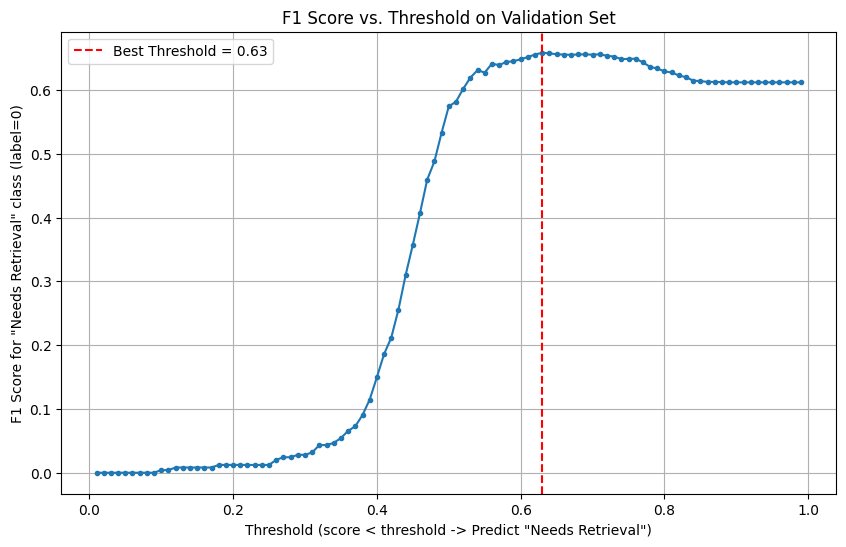


--- 步骤3: 正在测试集上使用最佳阈值进行最终评估 ---

--- 最终性能报告 (测试集) ---
使用的阈值: 0.63
精确率 (Precision for 'Needs Retrieval'): 0.4756
召回率 (Recall for 'Needs Retrieval'):    0.8246
F1 分数 (F1-Score for 'Needs Retrieval'):  0.6032
--------------------------------


In [2]:
import json
import joblib
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

# --- 1. 配置您的文件路径 (无需修改) ---
VALIDATION_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/medmcqa_test_dataset.json'
TEST_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json'
MODEL_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/lr_qwen_best_model.joblib'

# --- 2. 数据加载函数 (已根据您的样本更新) ---
def extract_features_and_labels(file_path):
    """
    加载数据并提取模型的输入特征(X)和黄金标准标签(y)。
    此版本已根据您提供的数据样本更新。
    """
    print(f"正在从 {file_path} 加载数据...")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        # 假设JSON文件内容是一个字典列表
        data = json.load(f)
        
    features = []
    labels = []
    
    # 遍历列表中的每个数据点
    for item in data:
        # 从 "normalized_truth_values" 键获取特征
        if 'normalized_truth_values' in item:
            features.append(item['normalized_truth_values'])
        else:
            raise ValueError(f"在文件 {file_path} 的一个数据项中找不到 'normalized_truth_values' 键。")
            
        # 从 "label" 键获取标签
        if 'label' in item:
            labels.append(item['label'])
        else:
            raise ValueError(f"在文件 {file_path} 的一个数据项中找不到 'label' 键。")
            
    X = np.array(features)
    y = np.array(labels)
    
    print(f"加载完成: {len(X)} 条数据。")
    return X, y


# --- 3. 主执行逻辑 ---
if __name__ == '__main__':
    # 加载模型
    print(f"正在加载模型: {MODEL_PATH}")
    model = joblib.load(MODEL_PATH)
    
    # 加载验证集和测试集数据
    X_val, y_val = extract_features_and_labels(VALIDATION_FILE_PATH)
    X_test, y_test = extract_features_and_labels(TEST_FILE_PATH)

    # --- 步骤2: 在验证集上寻找最佳阈值 ---
    print("\n--- 步骤2: 正在验证集上寻找最佳阈值 ---")
    
    # 模型输出的是 P(不检索) 的概率，即属于类别 1 的概率。
    # 我们使用 predict_proba 获取属于各个类别的概率。
    # scores_val 将是模型预测为“不需要检索”(类别1)的概率。
    scores_val = model.predict_proba(X_val)[:, 1]
    
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_f1 = -1.0
    best_threshold = 0
    f1_scores = []

    for threshold in thresholds:
        # 决策逻辑:
        # score 是 P(不检索)。
        # 如果 score >= threshold，我们相信它“不需要检索”，预测为 1。
        # 如果 score < threshold，我们认为它“需要检索”，预测为 0。
        y_pred = (scores_val >= threshold).astype(int)
        
        # *** 关键变更 ***
        # 我们关心的是正确识别“需要检索”(标签为0)的样本。
        # 因此，我们将 pos_label 设置为 0。
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, y_pred, average='binary', pos_label=0, zero_division=0
        )
        f1_scores.append(f1)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"\n在验证集上找到的最佳F1分数 (针对'需要检索'类别): {best_f1:.4f}")
    print(f"对应的最佳阈值: {best_threshold:.2f} (当模型分数 < {best_threshold:.2f} 时, 决策为'需要检索')")

    # 绘制F1分数随阈值变化的曲线
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, marker='.')
    plt.title('F1 Score vs. Threshold on Validation Set')
    plt.xlabel('Threshold (score < threshold -> Predict "Needs Retrieval")')
    plt.ylabel('F1 Score for "Needs Retrieval" class (label=0)')
    plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- 步骤3: 在测试集上进行最终评估 ---
    print("\n--- 步骤3: 正在测试集上使用最佳阈值进行最终评估 ---")
    
    scores_test = model.predict_proba(X_test)[:, 1]
    
    # 应用找到的最佳阈值
    y_pred_test = (scores_test >= best_threshold).astype(int)
    
    # 计算最终性能指标，同样，正类是 0
    final_precision, final_recall, final_f1, _ = precision_recall_fscore_support(
        y_test, y_pred_test, average='binary', pos_label=0, zero_division=0
    )
    
    print("\n--- 最终性能报告 (测试集) ---")
    print(f"使用的阈值: {best_threshold:.2f}")
    print(f"精确率 (Precision for 'Needs Retrieval'): {final_precision:.4f}")
    print(f"召回率 (Recall for 'Needs Retrieval'):    {final_recall:.4f}")
    print(f"F1 分数 (F1-Score for 'Needs Retrieval'):  {final_f1:.4f}")
    print("--------------------------------")

正在加载模型: /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/lr_qwen_best_model.joblib
正在从 /home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/medmcqa_test_dataset.json 加载数据...
加载完成: 1105 条数据。
正在从 /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json 加载数据...
加载完成: 5000 条数据。

--- 步骤2: 正在验证集上寻找最佳阈值 ---

在验证集上找到的最佳F1分数 (针对'需要检索'类别): 0.6583
对应的最佳阈值: 0.63 (当模型分数 < 0.63 时, 决策为'需要检索')


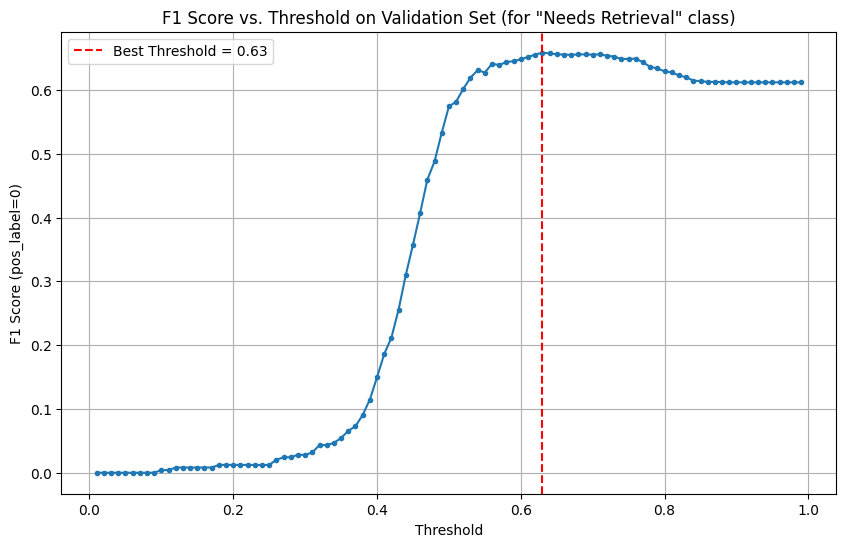


--- 步骤3: 正在测试集上使用最佳阈值进行最终评估 ---

使用的阈值: 0.63
--------------------------------------------------
--- 针对 '需要检索'(label=0) 的专项指标 ---
精确率 (Precision): 0.4756
召回率 (Recall):    0.8246
F1 分数 (F1-Score): 0.6032
--------------------------------------------------

--- 整体性能分类报告 (测试集) ---
                precision    recall  f1-score   support

需要检索 (label 0)     0.4756    0.8246    0.6032      1853
不需检索 (label 1)     0.8181    0.4646    0.5926      3147

      accuracy                         0.5980      5000
     macro avg     0.6468    0.6446    0.5979      5000
  weighted avg     0.6912    0.5980    0.5966      5000

--------------------------------------------------


In [1]:
# -------------------------------------------------------------------
# 导入所需库
# -------------------------------------------------------------------
import json
import joblib
import numpy as np
# 导入了 precision_recall_fscore_support 和新增的 classification_report
from sklearn.metrics import precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1. 配置您的文件路径 (请根据您的实际情况修改)
# -------------------------------------------------------------------
VALIDATION_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/medmcqa_test_dataset.json'
TEST_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/step2_final_simplified_results.json'
MODEL_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/lr_qwen_best_model.joblib'


# -------------------------------------------------------------------
# 2. 数据加载函数 (与您原版一致)
# -------------------------------------------------------------------
def extract_features_and_labels(file_path):
    """
    加载数据并提取模型的输入特征(X)和黄金标准标签(y)。
    """
    print(f"正在从 {file_path} 加载数据...")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    features = []
    labels = []
    
    for item in data:
        if 'normalized_truth_values' in item:
            features.append(item['normalized_truth_values'])
        else:
            raise ValueError(f"在文件 {file_path} 的一个数据项中找不到 'normalized_truth_values' 键。")
            
        if 'label' in item:
            labels.append(item['label'])
        else:
            raise ValueError(f"在文件 {file_path} 的一个数据项中找不到 'label' 键。")
            
    X = np.array(features)
    y = np.array(labels)
    
    print(f"加载完成: {len(X)} 条数据。")
    return X, y


# -------------------------------------------------------------------
# 3. 主执行逻辑
# -------------------------------------------------------------------
if __name__ == '__main__':
    # --- 步骤1: 加载模型和数据 ---
    print(f"正在加载模型: {MODEL_PATH}")
    try:
        model = joblib.load(MODEL_PATH)
    except FileNotFoundError:
        print(f"错误: 模型文件未找到, 请检查路径: {MODEL_PATH}")
        exit()
    
    try:
        X_val, y_val = extract_features_and_labels(VALIDATION_FILE_PATH)
        X_test, y_test = extract_features_and_labels(TEST_FILE_PATH)
    except FileNotFoundError as e:
        print(f"错误: 数据文件未找到, {e}")
        exit()
    except ValueError as e:
        print(f"错误: 数据格式问题, {e}")
        exit()


    # --- 步骤2: 在验证集上寻找最佳阈值 ---
    print("\n--- 步骤2: 正在验证集上寻找最佳阈值 ---")
    
    # scores_val 是模型预测为“不需要检索”(类别1)的概率。
    scores_val = model.predict_proba(X_val)[:, 1]
    
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_f1 = -1.0
    best_threshold = 0
    f1_scores = []

    for threshold in thresholds:
        # 如果 score >= threshold，预测为 1 (不需检索)
        # 如果 score < threshold，预测为 0 (需要检索)
        y_pred = (scores_val >= threshold).astype(int)
        
        # 我们关心的是正确识别“需要检索”(标签为0)的样本，因此 pos_label=0
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, y_pred, average='binary', pos_label=0, zero_division=0
        )
        f1_scores.append(f1)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"\n在验证集上找到的最佳F1分数 (针对'需要检索'类别): {best_f1:.4f}")
    print(f"对应的最佳阈值: {best_threshold:.2f} (当模型分数 < {best_threshold:.2f} 时, 决策为'需要检索')")

    # 绘制F1分数随阈值变化的曲线
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, marker='.')
    plt.title('F1 Score vs. Threshold on Validation Set (for "Needs Retrieval" class)')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score (pos_label=0)')
    plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- 步骤3: 在测试集上使用最佳阈值进行最终评估 ---
    print("\n--- 步骤3: 正在测试集上使用最佳阈值进行最终评估 ---")
    
    scores_test = model.predict_proba(X_test)[:, 1]
    
    # 应用找到的最佳阈值
    y_pred_test = (scores_test >= best_threshold).astype(int)
    
    # --- 最终性能报告 (测试集) ---
    print(f"\n使用的阈值: {best_threshold:.2f}")
    print("--------------------------------------------------")

    # 报告1: 针对您优化的目标类别 "需要检索" 的专项指标
    final_precision, final_recall, final_f1, _ = precision_recall_fscore_support(
        y_test, y_pred_test, average='binary', pos_label=0, zero_division=0
    )
    print("--- 针对 '需要检索'(label=0) 的专项指标 ---")
    print(f"精确率 (Precision): {final_precision:.4f}")
    print(f"召回率 (Recall):    {final_recall:.4f}")
    print(f"F1 分数 (F1-Score): {final_f1:.4f}")
    print("--------------------------------------------------\n")

    # 报告2: 新增的、更全面的整体性能分类报告
    print("--- 整体性能分类报告 (测试集) ---")
    # 定义类别名称，让报告更易读
    target_names = ['需要检索 (label 0)', '不需检索 (label 1)'] 
    # 使用 classification_report 打印所有指标，digits=4 保留四位小数
    report = classification_report(y_test, y_pred_test, target_names=target_names, digits=4)
    print(report)
    print("--------------------------------------------------")

In [5]:
# import json
# processed_dataset_path = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl'
# my_test_dataset = []
# try:
#     with open(processed_dataset_path, 'r', encoding='utf-8') as f:
#         for line in f:
#             if line.strip():
#                 my_test_dataset.append(json.loads(line))
#     print(f"成功加载处理好的数据集: {processed_dataset_path}")
# except FileNotFoundError:
#     print(f"错误：找不到处理好的数据集文件 -> {processed_dataset_path}")
#     print("请先运行上一步 代码！")
#     exit() # 如果文件不存在，则退出

成功加载处理好的数据集: /home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl


In [8]:
# my_test_dataset[0]

{'context': '',
 'question': 'Which of the following is true regarding major basic protein?\nA) Formed by Eosinophils\nB) Cytotoxic to parasites\nC) Not very effective against bacteria\nD) All the above',
 'ground_truths': ['D) All the above']}

FLARE（Direct）基线

Demo

In [3]:
# 导入必要的库
import json
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from openai import OpenAI
import httpx
import re

# 设置环境变量
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ["OPENAI_API_KEY"] = 'sk-G8CJQUKCn17H6E3140C3166f4dF9447d9c8c4a1f56B77e66'
os.environ["OPENAI_API_BASE"] = "https://api.xty.app/v1"

# 定义数据集路径
processed_dataset_path = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl'

# 步骤 1：加载数据集的第一条数据
print("=== 步骤 1：加载数据集的第一条数据 ===")
try:
    with open(processed_dataset_path, 'r', encoding='utf-8') as f:
        first_line = f.readline().strip()  # 读取第一行并去除空白
        if first_line:
            first_item = json.loads(first_line)  # 解析为 JSON 对象
            print("数据集第一条数据：")
            print(json.dumps(first_item, indent=2, ensure_ascii=False))  # 美化输出
        else:
            print("错误：数据集文件为空！")
            exit()
except FileNotFoundError:
    print(f"错误：找不到数据集文件 -> {processed_dataset_path}")
    exit()

# 步骤 2：加载 LLaMA 模型和分词器
# print("\n=== 步骤 2：加载 LLaMA-3.1-8B-Instruct 模型和分词器 ===")
print("\n=== 步骤 2：加载 Qwen-2.5-7B-Instruct 模型和分词器 ===")
model = AutoModelForCausalLM.from_pretrained(
    "/mnt/zhangjinshuo/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "/mnt/zhangjinshuo/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28",
    use_fast=False
)
print("模型和分词器加载完成！")

# 步骤 3：初始化 OpenAI 客户端
print("\n=== 步骤 3：初始化 OpenAI 客户端 ===")
client = OpenAI(
    base_url=os.environ["OPENAI_API_BASE"],
    api_key=os.environ["OPENAI_API_KEY"],
    http_client=httpx.Client(
        base_url=os.environ["OPENAI_API_BASE"],
        follow_redirects=True,
    ),
)
print("OpenAI 客户端初始化完成！")

# 步骤 4：定义函数 - 获取模型生成的答案和 token 概率
def get_generated_answer_and_probs(question):
    # 定义 system prompt
    system_prompt = "You are a medical question-answering assistant. Provide only the direct answer to the question, without any explanation, additional information, or context. The answer should be concise and match one of the provided options exactly (e.g., 'A)', 'B)', 'C)', 'D)')."
    # 定义用户提示
    user_prompt = f"Question: {question}\nAnswer: "
    
    print("\n=== 步骤 4.1：构造提示 ===")
    print(f"System Prompt:\n{system_prompt}")
    print(f"User Prompt:\n{user_prompt}")

    # 构造 messages 格式以支持 system 和 user 提示
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    # 将 messages 转换为模型可接受的提示格式
    prompt = tokenizer.apply_chat_template(messages, tokenize=False)
    
    print("\n=== 步骤 4.2：对提示进行分词 ===")
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    print(f"输入 token 数量：{inputs.input_ids.shape[1]}")

    print("\n=== 步骤 4.3：生成答案 ===")
    outputs = model.generate(
        **inputs,
        max_new_tokens=15,
        output_scores=True,
        return_dict_in_generate=True,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    
    # 提取生成的 token
    generated_tokens = outputs.sequences[0][inputs.input_ids.shape[1]:]
    generated_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    # 清理生成答案：去除多余的标记、换行符和前缀
    generated_answer = re.sub(r'^(assistant\s*[\n]*|[\n\s]*)', '', generated_answer).strip()
    generated_answer = re.sub(r'[\n\s]*$', '', generated_answer).strip()
    
    print(f"生成答案（清理后）：{generated_answer}")
    
    # 计算 token 概率
    token_probs = []
    print("\n=== 步骤 4.4：计算生成 token 的概率 ===")
    for i, score in enumerate(outputs.scores):
        probs = torch.softmax(score, dim=-1)
        token_id = outputs.sequences[0][inputs.input_ids.shape[1] + i]
        prob = probs[0, token_id].item()
        token = tokenizer.decode([token_id], skip_special_tokens=True)
        print(f"Token {i+1}: '{token}', 概率: {prob:.4f}")
        token_probs.append(prob)
    
    # 判断是否需要检索
    needs_retrieval = any(prob < 0.8 for prob in token_probs)
    print(f"\n是否需要检索（任一 token 概率 < 0.8）：{needs_retrieval}")
    
    return generated_answer, needs_retrieval

# 步骤 5：定义函数 - 使用 GPT-4o-mini 判断答案正确性
def get_label_from_gpt(ground_truth, generated_answer):
    print("\n=== 步骤 5.1：准备 GPT-4o-mini 提示 ===")
    system_prompt = (
        "You are a precise evaluator. Your task is to determine if a 'Generated Answer' is "
        "semantically identical to the 'Ground Truth' answer for a multiple-choice question. "
        "They are identical if they refer to the same option, even with minor formatting differences "
        "(e.g., 'A)' vs 'A.' or containing extra text like 'The answer is...'). "
        "Respond with only the single word 'yes' or 'no', and nothing else."
    )
    user_prompt = f"Ground Truth: {ground_truth}\nGenerated Answer: {generated_answer}"
    print(f"System Prompt:\n{system_prompt}")
    print(f"User Prompt:\n{user_prompt}")
    
    print("\n=== 步骤 5.2：调用 GPT-4o-mini API ===")
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0,
            max_tokens=5
        )
        gpt_response = response.choices[0].message.content.strip().lower()
        print(f"GPT-4o-mini 响应：{gpt_response}")
        return 1 if gpt_response == "yes" else 0
    except Exception as e:
        print(f"调用 GPT API 时出错: {e}")
        print(f"出错的样本 -> Ground Truth: {ground_truth}, Generated Answer: {generated_answer}")
        return -1

# 步骤 6：处理数据集第一条数据
print("\n=== 步骤 6：处理数据集第一条数据 ===")
question = first_item['question']
ground_truth = first_item['ground_truths'][0]  # 假设 ground_truths 是一个列表
print(f"问题：{question}")
print(f"标准答案：{ground_truth}")

# 获取生成答案和是否需要检索
generated_answer, needs_retrieval = get_generated_answer_and_probs(question)

# 使用 GPT-4o-mini 判断答案正确性
is_correct = get_label_from_gpt(ground_truth, generated_answer)

# 添加新字段
first_item['needs_retrieval'] = needs_retrieval
first_item['is_correct'] = is_correct
first_item['generated_answer'] = generated_answer

# 步骤 7：输出处理结果
print("\n=== 步骤 7：输出处理结果 ===")
print("处理后的数据：")
print(json.dumps(first_item, indent=2, ensure_ascii=False))

# 步骤 8：保存处理结果到文件
output_path = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据_demo.jsonl'
print("\n=== 步骤 8：保存处理结果 ===")
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(json.dumps(first_item, ensure_ascii=False) + '\n')
print(f"✅ 处理完成！结果已保存至 {output_path}")

=== 步骤 1：加载数据集的第一条数据 ===
数据集第一条数据：
{
  "context": "",
  "question": "Which of the following is true regarding major basic protein?\nA) Formed by Eosinophils\nB) Cytotoxic to parasites\nC) Not very effective against bacteria\nD) All the above",
  "ground_truths": [
    "D) All the above"
  ]
}

=== 步骤 2：加载 Qwen-2.5-7B-Instruct 模型和分词器 ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

模型和分词器加载完成！

=== 步骤 3：初始化 OpenAI 客户端 ===
OpenAI 客户端初始化完成！

=== 步骤 6：处理数据集第一条数据 ===
问题：Which of the following is true regarding major basic protein?
A) Formed by Eosinophils
B) Cytotoxic to parasites
C) Not very effective against bacteria
D) All the above
标准答案：D) All the above

=== 步骤 4.1：构造提示 ===
System Prompt:
You are a medical question-answering assistant. Provide only the direct answer to the question, without any explanation, additional information, or context. The answer should be concise and match one of the provided options exactly (e.g., 'A)', 'B)', 'C)', 'D)').
User Prompt:
Question: Which of the following is true regarding major basic protein?
A) Formed by Eosinophils
B) Cytotoxic to parasites
C) Not very effective against bacteria
D) All the above
Answer: 

=== 步骤 4.2：对提示进行分词 ===
输入 token 数量：118

=== 步骤 4.3：生成答案 ===
生成答案（清理后）：pestic
user
Answer: D)

=== 步骤 4.4：计算生成 token 的概率 ===
Token 1: '', 概率: 0.9992
Token 2: ' pestic', 概率: 0.0158
Token 3: '
', 概率: 0.7336
Token 4: '', 概率: 

完整数据

In [1]:
import json
import torch
import os
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig
from openai import OpenAI
import httpx
import re

# 设置 transformers 日志级别为 error 以隐藏警告
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

# 数据集路径
processed_dataset_path = '/home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl'

# 加载数据集
my_test_dataset = []
try:
    with open(processed_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                my_test_dataset.append(json.loads(line))
    print(f"成功加载处理好的数据集: {processed_dataset_path}")
except FileNotFoundError:
    print(f"错误：找不到处理好的数据集文件 -> {processed_dataset_path}")
    print("请先运行上一步代码！")
    exit()

# 加载模型和分词器
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
model = AutoModelForCausalLM.from_pretrained(
    "/mnt/zhangjinshuo/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "/mnt/zhangjinshuo/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28/",
    use_fast=False
)
print("模型和分词器加载完成！")

# 初始化OpenAI客户端
os.environ["OPENAI_API_KEY"] = 'sk-G8CJQUKCn17H6E3140C3166f4dF9447d9c8c4a1f56B77e66'
os.environ["OPENAI_API_BASE"] = "https://api.xty.app/v1"
client = OpenAI(
    base_url=os.environ["OPENAI_API_BASE"],
    api_key=os.environ["OPENAI_API_KEY"],
    http_client=httpx.Client(
        base_url=os.environ["OPENAI_API_BASE"],
        follow_redirects=True,
    ),
)
print("OpenAI 客户端初始化完成！")

# --- 代码修改部分 ---
# 1. 预先定义 GenerationConfig
# 这样可以避免每次循环都创建对象，并能消除关于 temperature/top_p 的警告
generation_config = GenerationConfig(
    max_new_tokens=50,
    output_scores=True,
    return_dict_in_generate=True,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)
# --- 修改结束 ---

# 定义函数：获取模型生成的答案及其token概率
def get_generated_answer_and_probs(question):
    # 定义 system prompt
    system_prompt = "You are a medical question-answering assistant. Provide only the direct answer to the question, without any explanation, additional information, or context. The answer should be concise and match one of the provided options exactly (e.g., 'A)', 'B)', 'C)', 'D)')."
    # 定义用户提示
    user_prompt = f"Question: {question}\nAnswer: "
    
    # 构造 messages 格式以支持 system 和 user 提示
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    # 将 messages 转换为模型可接受的提示格式
    prompt = tokenizer.apply_chat_template(messages, tokenize=False)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # --- 代码修改部分 ---
    # 2. 在 model.generate 中使用定义好的 generation_config
    outputs = model.generate(
        **inputs,
        generation_config=generation_config
    )
    # --- 修改结束 ---
    
    # 获取生成的答案
    generated_tokens = outputs.sequences[0][inputs.input_ids.shape[1]:]  # 去除输入部分的token
    generated_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    # 清理生成答案：去除多余的标记、换行符和前缀
    generated_answer = re.sub(r'^(assistant\s*[\n]*|[\n\s]*)', '', generated_answer).strip()
    generated_answer = re.sub(r'[\n\s]*$', '', generated_answer).strip()
    
    # 计算每个token的概率
    token_probs = []
    for i, score in enumerate(outputs.scores):
        probs = torch.softmax(score, dim=-1)
        token_id = outputs.sequences[0][inputs.input_ids.shape[1] + i]
        prob = probs[0, token_id].item()
        token_probs.append(prob)
    
    # 检查是否存在概率低于0.8的token
    needs_retrieval = any(prob < 0.8 for prob in token_probs)
    
    return generated_answer, needs_retrieval

# 定义函数：使用gpt-4o-mini判断答案是否正确
def get_label_from_gpt(ground_truth, generated_answer):
    system_prompt = (
        "You are a precise evaluator. Your task is to determine if a 'Generated Answer' is "
        "semantically identical to the 'Ground Truth' answer for a multiple-choice question. "
        "They are identical if they refer to the same option, even with minor formatting differences "
        "(e.g., 'A)' vs 'A.' or containing extra text like 'The answer is...'). "
        "Respond with only the single word 'yes' or 'no', and nothing else."
    )
    user_prompt = f"Ground Truth: {ground_truth}\nGenerated Answer: {generated_answer}"
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0,
            max_tokens=5
        )
        gpt_response = response.choices[0].message.content.strip().lower()
        return 1 if gpt_response == "yes" else 0
    except Exception as e:
        print(f"调用 GPT API 时出错: {e}")
        print(f"出错的样本 -> Ground Truth: {ground_truth}, Generated Answer: {generated_answer}")
        return -1

# 处理数据集并添加新字段
labeled_dataset = []
for item in tqdm(my_test_dataset, desc="处理数据集"):
    question = item['question']
    ground_truth = item['ground_truths'][0]  # 假设ground_truths是一个列表，取第一个
    
    # 获取模型生成的答案和是否需要检索
    generated_answer, needs_retrieval = get_generated_answer_and_probs(question)
    
    # 使用gpt-4o-mini判断答案是否正确
    is_correct = get_label_from_gpt(ground_truth, generated_answer)
    
    # 添加新字段
    item['needs_retrieval'] = needs_retrieval
    item['is_correct'] = is_correct
    item['generated_answer'] = generated_answer  # 可选：保存生成的答案
    labeled_dataset.append(item)

# 保存处理后的数据集
output_path = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据.jsonl'
with open(output_path, 'w', encoding='utf-8') as f:
    for item in labeled_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"✅ 处理完成！共处理了 {len(labeled_dataset)} 条数据，已保存至 {output_path}")


成功加载处理好的数据集: /home/qluai/zjs/MedMCQA数据处理/medmcqa/train_formatted_sample_5000.jsonl


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

模型和分词器加载完成！
OpenAI 客户端初始化完成！


处理数据集: 100%|██████████| 5000/5000 [4:35:46<00:00,  3.31s/it]    

✅ 处理完成！共处理了 5000 条数据，已保存至 /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据.jsonl


In [2]:
import json
processed_dataset_path = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据.jsonl'
flare_test_dataset = []
try:
    with open(processed_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                flare_test_dataset.append(json.loads(line))
    print(f"成功加载处理好的数据集: {processed_dataset_path}")
except FileNotFoundError:
    print(f"错误：找不到处理好的数据集文件 -> {processed_dataset_path}")
    exit() # 如果文件不存在，则退出

成功加载处理好的数据集: /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据.jsonl


In [3]:
flare_test_dataset[1]

{'context': '',
 'question': 'Pruritis (Itching) is caused by deficiency of -\nA) HMB synthase\nB) 5-ALA dehydratase\nC) Uroporphyrinogen - I synthase\nD) Uroporphyrinogen - III synthase',
 'ground_truths': ['D) Uroporphyrinogen - III synthase'],
 'needs_retrieval': True,
 'is_correct': 0,
 'generated_answer': 'ítica\nuser\nAnswer: A) HMB synthase'}

In [4]:
import json

# 加载数据集
processed_dataset_path = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据.jsonl'
flare_test_dataset = []
try:
    with open(processed_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                flare_test_dataset.append(json.loads(line))
    print(f"成功加载处理好的数据集: {processed_dataset_path}")
except FileNotFoundError:
    print(f"错误：找不到处理好的数据集文件 -> {processed_dataset_path}")
    exit()

# 初始化计数器
TP_retrieval = 0  # 需要检索：needs_retrieval == True 且 is_correct == 0
FP_retrieval = 0  # 需要检索：needs_retrieval == True 且 is_correct == 1
FN_retrieval = 0  # 需要检索：needs_retrieval == False 且 is_correct == 0
TN_retrieval = 0  # 需要检索：needs_retrieval == False 且 is_correct == 1

# 遍历数据集，统计计数
for entry in flare_test_dataset:
    needs_retrieval = entry['needs_retrieval']
    is_correct = entry['is_correct']
    
    if needs_retrieval and is_correct == 0:
        TP_retrieval += 1
    elif needs_retrieval and is_correct == 1:
        FP_retrieval += 1
    elif not needs_retrieval and is_correct == 0:
        FN_retrieval += 1
    elif not needs_retrieval and is_correct == 1:
        TN_retrieval += 1

# 计算“需要检索”类别的指标
total = TP_retrieval + FP_retrieval + FN_retrieval + TN_retrieval
if total == 0:
    print("数据集为空，无法计算指标！")
    exit()

# “需要检索”类别
recall_retrieval = TP_retrieval / (TP_retrieval + FN_retrieval) if (TP_retrieval + FN_retrieval) > 0 else 0.0
precision_retrieval = TP_retrieval / (TP_retrieval + FP_retrieval) if (TP_retrieval + FP_retrieval) > 0 else 0.0
f1_retrieval = (2 * precision_retrieval * recall_retrieval) / (precision_retrieval + recall_retrieval) if (precision_retrieval + recall_retrieval) > 0 else 0.0

# “不需要检索”类别
# 注意：对于“不需要检索”，TP = TN_retrieval, FP = FN_retrieval, FN = FP_retrieval
recall_no_retrieval = TN_retrieval / (TN_retrieval + FP_retrieval) if (TN_retrieval + FP_retrieval) > 0 else 0.0
precision_no_retrieval = TN_retrieval / (TN_retrieval + FN_retrieval) if (TN_retrieval + FN_retrieval) > 0 else 0.0
f1_no_retrieval = (2 * precision_no_retrieval * recall_no_retrieval) / (precision_no_retrieval + recall_no_retrieval) if (precision_no_retrieval + recall_no_retrieval) > 0 else 0.0

# 打印结果
print(f"总样本数: {total}")
print("\n=== 需要检索类别 ===")
print(f"TP (正确预测需要检索): {TP_retrieval}")
print(f"FP (错误预测需要检索): {FP_retrieval}")
print(f"FN (漏掉需要检索): {FN_retrieval}")
print(f"TN (正确预测不需要检索): {TN_retrieval}")
print(f"召回率 (Recall): {recall_retrieval:.4f}")
print(f"精确率 (Precision): {precision_retrieval:.4f}")
print(f"F1分数 (F1 Score): {f1_retrieval:.4f}")

print("\n=== 不需要检索类别 ===")
print(f"TP (正确预测不需要检索): {TN_retrieval}")
print(f"FP (错误预测不需要检索): {FN_retrieval}")
print(f"FN (漏掉不需要检索): {FP_retrieval}")
print(f"TN (正确预测需要检索): {TP_retrieval}")
print(f"召回率 (Recall): {recall_no_retrieval:.4f}")
print(f"精确率 (Precision): {precision_no_retrieval:.4f}")
print(f"F1分数 (F1 Score): {f1_no_retrieval:.4f}")

成功加载处理好的数据集: /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/flare基线相关数据.jsonl
总样本数: 5000

=== 需要检索类别 ===
TP (正确预测需要检索): 4105
FP (错误预测需要检索): 805
FN (漏掉需要检索): 64
TN (正确预测不需要检索): 26
召回率 (Recall): 0.9846
精确率 (Precision): 0.8360
F1分数 (F1 Score): 0.9043

=== 不需要检索类别 ===
TP (正确预测不需要检索): 26
FP (错误预测不需要检索): 64
FN (漏掉不需要检索): 805
TN (正确预测需要检索): 4105
召回率 (Recall): 0.0313
精确率 (Precision): 0.2889
F1分数 (F1 Score): 0.0565
